In [16]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

In [17]:
from functools import partial

import jax
import jax.numpy as jnp
import netket as nk
from flax import nnx
from netket.experimental.operator import FermiHubbardJax

**Setup:**
Consider a $L \times L$ square lattice in momentum space. The Hubbard Hamiltonian reads:

$\newcommand{\bsl}[1]{\boldsymbol{#1}}$
\begin{align}
\mathcal{H}_0 &= \sum_{\bsl{k}, \sigma} \varepsilon(\bsl{k}) c*{\bsl{k}\sigma}^{\dagger}c*{\bsl{k}\sigma} \\
\mathcal{H}_{\text{int}} &= \frac{U}{L^2} \sum_{\bsl{k}, \bsl{k'}, \bsl{q}} c*{\bsl{k}+\bsl{q}, \uparrow}^{\dagger} c*{\bsl{k}, \uparrow} c*{\bsl{k'}-\bsl{q}, \downarrow}^{\dagger} c*{\bsl{k'}, \downarrow} \\
\mathcal{H} &= \mathcal{H}_0 + \mathcal{H}_{\text{int}},
\end{align}

where $\varepsilon(\bsl{k}) = -2t\left(\cos (k_x) + \cos(k_y)\right)$, $U$ is the on-site repulsion, and $t$ is the hopping parameter. If we convert this Hamiltonian to real space (which is what our NN expects for input), we get:

$$\mathcal{H}=-t\sum_{\langle{\bsl{i}}, \bsl{j}\rangle{},\sigma} \left(c_{\bsl{i}\sigma}^{\dagger} c_{\bsl{j}\sigma} + c_{\bsl{j}\sigma}^{\dagger} c_{\bsl{i}\sigma}\right) + U\sum_{\bsl{i}}n_{\bsl{i}\uparrow}n_{\bsl{i}\downarrow}$$

**Goal:**
We need to minimize
$$E = \frac{\langle{\Psi}|\mathcal{H}|\Psi\rangle{}}{\langle{\Psi}|\Psi\rangle{}}$$


In [18]:
# Model parameters
L = 4
n = 10
diff = 0
t = 1.0
U = 2.0

# diff = n_spin_up - n_spin_down
# diff and n should have the same parity
n_spin_up = (n + diff) // 2
n_spin_down = (n - diff) // 2

In [19]:
# make the lattice
lattice = nk.graph.Square(L, pbc=True)
num_lattice_sites = lattice.n_nodes
print(f"{num_lattice_sites = }")

num_lattice_sites = 16


In [20]:
# make the Hilbert Space
hi = nk.hilbert.SpinOrbitalFermions(
    num_lattice_sites, s=1 / 2, n_fermions_per_spin=(n_spin_down, n_spin_up)
)

In [21]:
# 1. Generate a random batch of 5 configurations directly from the Hilbert space
key = jax.random.PRNGKey(42)
mock_x = hi.random_state(key, size=5)

print(f"Shape of mock_x from Hilbert space: {mock_x.shape}")
print(f"What mock_x looks like:\n{mock_x}")

Shape of mock_x from Hilbert space: (5, 32)
What mock_x looks like:
[[1 1 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 0 1 1 0 0 0 0 0 0 0 1 0 1 0]
 [1 0 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 1 1 0 1 1 0 0 0 0 0 0 0]
 [0 1 0 1 0 0 0 0 0 0 1 1 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 1 0 0 0 1]
 [0 1 1 1 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1]
 [0 0 0 0 0 0 0 0 1 1 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0]]


In [22]:
# define the Hamiltonian
H = FermiHubbardJax(hilbert=hi, t=t, U=U, graph=lattice)
print(f"{H.max_conn_size=}")

H.max_conn_size=41


In [23]:
# now implement the NN ansatz

# generic MLP helper class
class MLP(nnx.Module):
    def __init__(
        self,
        hidden_layers: int,
        input_dim: int,
        dim_feedforward: int,
        output_dim: int,
        rngs: nnx.Rngs,
        activation=nnx.gelu,
        # Pass the initializer function here
        kernel_init=nnx.initializers.lecun_normal(), 
        bias_init=nnx.initializers.zeros_init(),
    ):
        # Initial layer
        net = [
            nnx.Linear(input_dim, dim_feedforward, rngs=rngs, 
                       kernel_init=kernel_init, bias_init=bias_init),
            activation,
        ]
        
        # Hidden layers
        for _ in range(hidden_layers):
            net.append(nnx.Linear(dim_feedforward, dim_feedforward, rngs=rngs, 
                                  kernel_init=kernel_init, bias_init=bias_init))
            net.append(activation)
            
        # Output layer
        net.append(nnx.Linear(dim_feedforward, output_dim, rngs=rngs, 
                              kernel_init=kernel_init, bias_init=bias_init))
        
        self.MLP = nnx.Sequential(*net)

    def __call__(self, x: jax.Array):
        return self.MLP(x)


# quick helper function
def view_as_complex(x: jax.Array):
    return x[..., 0] + (1j * x[..., 1])


# component modules
class g_symmetric(nnx.Module):
    def __init__(
        self,
        L: int,
        hidden_layers: int,
        dim_feedforward: int,
        rngs: nnx.Rngs,
        activation=nnx.gelu,
        kernel_init=nnx.initializers.lecun_normal(), 
        bias_init=nnx.initializers.zeros_init(),
    ):
        # weights, drawn from a Gaussian distribution (for now)
        self.w_s = nnx.Param(rngs.normal((2 * (L**2),)))
        # instantiate MLP
        self.g_prime = MLP(hidden_layers, 1, dim_feedforward, 2, rngs, activation, kernel_init, bias_init)

    def __call__(self, occ_num: jax.Array):
        # occ_num should be of shape (batch_size, 2*L^2) in an occupation-number basis
        # to calculate eta, take matrix-vector product with w_s
        eta = jnp.expand_dims(
            jnp.matmul(occ_num, self.w_s), axis=-1
        )  # shape (batch_size, 1), dtype=float
        # now pass through MLP
        return view_as_complex(self.g_prime(eta))  # shape (batch_size), dtype=complex

# antisymmetric factor $F: \widetilde{\Lambda}^n \rightarrow \mathbb{C}$
class F_antisymmetric(nnx.Module):
    def __init__(
        self,
        n: int,
        rngs: nnx.Rngs,
    ):
        # learnable complex parameters
        # also initialized from a standard normal distribution (for now)
        self.real_part = nnx.Param(rngs.normal((3, n)) / jnp.sqrt(2))
        self.imag_part = nnx.Param(rngs.normal((3, n)) / jnp.sqrt(2))

    def __call__(self, x: jax.Array):
        # x should be of shape (batch_size, n, 3)
        # last dim is (x mod L, y mod L, spin)
        exponent = jnp.matmul(x, self.real_part) + (1j * jnp.matmul(x, self.imag_part))
        A = jnp.exp(1j * exponent) # shape (batch_size, n, n), dtype=complex
        # now take determinant
        sign, logabsdet = jnp.linalg.slogdet(A)
        return (
            sign,  # complex
            logabsdet,  # real
        )  # both should be vectors of shape (batch_size)


# wrapper class
class Psi_term(nnx.Module):
    def __init__(
        self,
        L: int,
        n: int,
        hidden_layers: int,
        dim_feedforward: int,
        rngs: nnx.Rngs,
        activation=nnx.gelu,
        kernel_init=nnx.initializers.lecun_normal(), 
        bias_init=nnx.initializers.zeros_init(),
    ):
        self.g = g_symmetric(L, hidden_layers, dim_feedforward, rngs, activation, kernel_init, bias_init)
        self.F = F_antisymmetric(n, rngs)
    
    def __call__(self, x: jax.Array, occ_num: jax.Array):
        # compute the antisymmetric function F
        sign, logabsdet = self.F(x)
        # compute the symmetric function g
        g = self.g(occ_num)
        return sign * g, logabsdet


class log_psi_2D_spinful(nnx.Module):
    def __init__(
        self,
        L: int,
        n: int,
        num_terms: int,
        hidden_layers: int,
        dim_feedforward: int,
        rngs: nnx.Rngs,
        activation=nnx.gelu,
        kernel_init=nnx.initializers.lecun_normal(), 
        bias_init=nnx.initializers.zeros_init(),
    ):
        self.L = L
        self.n = n
        # instantiate symmetric/antisymmetric factors
        self.terms = nnx.List([Psi_term(L, n, hidden_layers, dim_feedforward, rngs, activation, kernel_init, bias_init) for _ in range(num_terms)])

    def __call__(self, occ_num: jax.Array):
        # occ_num should be of shape (batch_size, 2*L^2) in an occupation-number basis
        # i = (\sigma L + x)L + y = \sigma L^2 + xL + y
        # convert to x format once for antisymmetric factors
        _, nonzero_indices = jax.lax.top_k(occ_num, k=self.n, axis=-1)
        y_indices = nonzero_indices % self.L
        temp = nonzero_indices // self.L
        x_indices = temp % self.L
        spin_indices = temp // self.L
        # now we have x, y, and \sigma
        x = jnp.stack(
            [
                x_indices,
                y_indices,
                (2 * spin_indices) - 1,  # encode spin as ±1
            ],
            axis=-1,
        )  # should be (batch_size, n, 3) now

        # lists to hold results
        a_list = []
        b_list = []
        for psi_term in self.terms:
            b_i, a_i = psi_term(x, occ_num) # complex/real vectors of shape (batch_size)
            a_list.append(a_i)
            b_list.append(b_i)
        
        # stack them together
        a = jnp.stack(a_list, axis=-1)
        b = jnp.stack(b_list, axis=-1)

        # finally take the log of the wavefunction
        log_psi = jax.nn.logsumexp(a=a, axis=-1, b=b)
        return log_psi  # shape (batch_size), dtype=complex

In [24]:
# Instantiate the NN model
model = log_psi_2D_spinful(
    L,
    n,
    num_terms=4,
    hidden_layers=3,
    dim_feedforward=128,
    rngs=nnx.Rngs(0),
    activation=nnx.gelu,
    kernel_init=nnx.initializers.lecun_normal(), 
    bias_init=nnx.initializers.zeros_init(),
)
print(model)

log_psi_2D_spinful( # Param: 200,568 (803.7 KB)
  L=4,
  n=10,
  terms=List([
    Psi_term( # Param: 50,142 (200.9 KB)
      g=g_symmetric( # Param: 50,082 (200.5 KB)
        w_s=Param( # 32 (256 B)
          value=Array(shape=(32,), dtype=dtype('float64'))
        ),
        g_prime=MLP( # Param: 50,050 (200.2 KB)
          MLP=Sequential( # Param: 50,050 (200.2 KB)
            layers=List([
              Linear( # Param: 256 (1.0 KB)
                kernel=Param( # 128 (512 B)
                  value=Array(shape=(1, 128), dtype=dtype('float32'))
                ),
                bias=Param( # 128 (512 B)
                  value=Array(shape=(128,), dtype=dtype('float32'))
                ),
                in_features=1,
                out_features=128,
                use_bias=True,
                dtype=None,
                param_dtype=float32,
                precision=None,
                dot_general=<function dot_general at 0x14aa20cd14e0>,
                promote_dtype=<func

In [25]:
# Define a Metropolis exchange sampler
exchange_graph = nk.graph.disjoint_union(lattice, lattice)
print(f"Exchange graph size: {exchange_graph.n_nodes}")
sa = nk.sampler.MetropolisExchange(hi, graph=exchange_graph)
print(sa)

Exchange graph size: 32
MetropolisSampler(rule = ExchangeRule(# of clusters: 64), n_chains = 16, sweep_size = 32, reset_chains = False, machine_power = 2, dtype = int8)


In [26]:
# Define an optimizer
op = nk.optimizer.Sgd(learning_rate=0.01)

# Create a variational state
vstate = nk.vqs.MCState(sa, model, n_samples=512, n_discard_per_chain=100)

# Create a Variational Monte Carlo with SR driver
gs = nk.driver.VMC_SR(
    H,
    op,
    variational_state=vstate,
    diag_shift=0.1,
    linear_solver=nk.optimizer.solver.pinv_smooth,
    mode="complex",
)

# Construct the logger to visualize the data later on
NN_log = nk.logging.RuntimeLog()

# Run the optimization for _ iterations
gs.run(n_iter=50_000, out=NN_log)

Automatic SR implementation choice:  NTK


  0%|          | 205/50000 [33:32<135:46:05,  9.82s/it, Energy=-20.01-0.01j ± 0.13 [σ²=8.9e+00, R̂=1.042]]   


KeyboardInterrupt: 

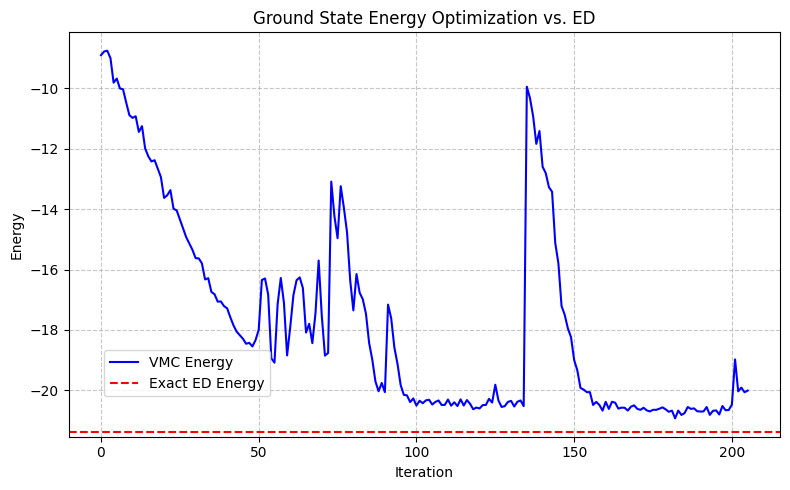

In [27]:
import matplotlib.pyplot as plt

# Extract iterations and the mean energy values from the log
iters = NN_log["Energy"].iters
energy = NN_log["Energy"]["Mean"].real

# Exact ground state energy from your ED code
E_gs = -21.38

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(iters, energy, color='blue', label='VMC Energy')

# Add the exact ED energy as a horizontal dashed line
plt.axhline(y=E_gs, color='red', linestyle='--', label='Exact ED Energy')

# Formatting the plot
plt.xlabel('Iteration')
plt.ylabel('Energy')
plt.title('Ground State Energy Optimization vs. ED')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc=(0.05, 0.1))

# Show the plot
plt.tight_layout()
plt.show()

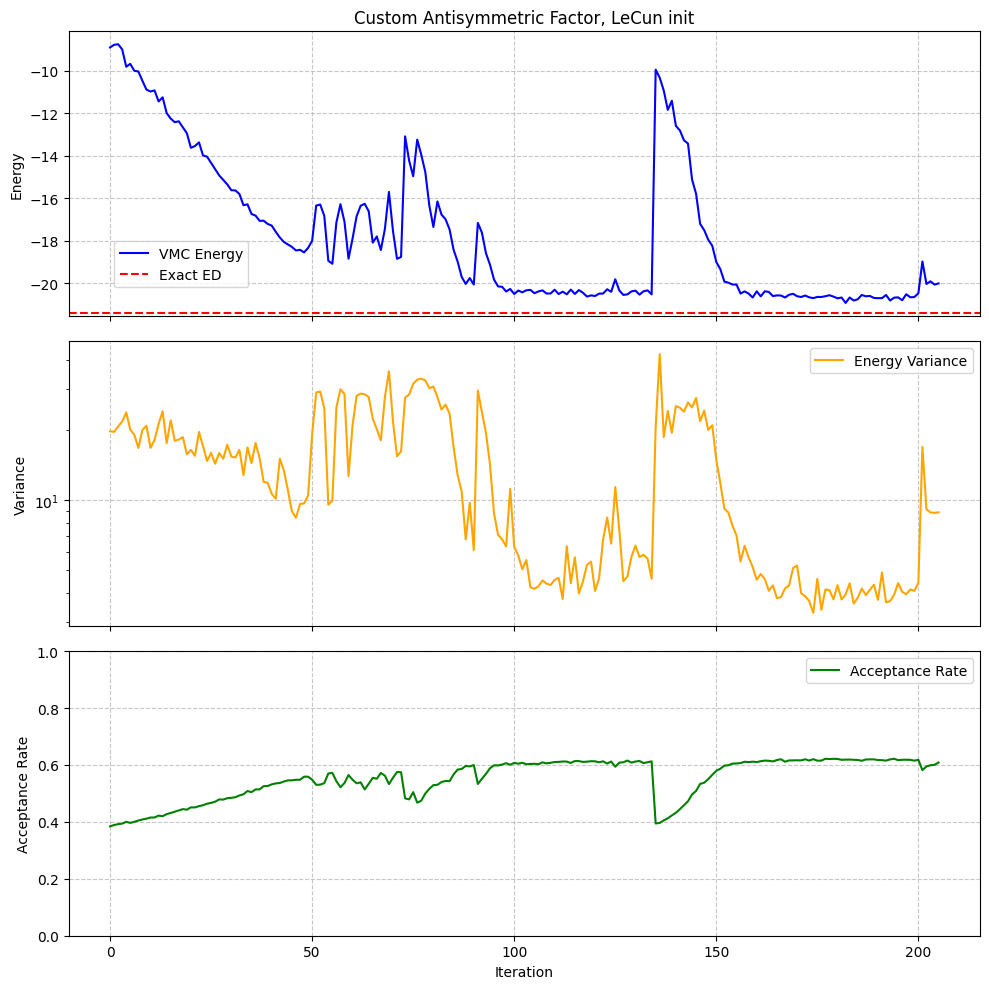

In [29]:
# Extract data from the log
variance = NN_log["Energy"]["Variance"].real

# Acceptance is just a raw scalar history, not a Stats object
acceptance = NN_log["acceptance"].value

# Create a 3-panel plot
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# 1. Energy Plot
ax1.plot(iters, energy, color='blue', label='VMC Energy')
ax1.axhline(y=E_gs, color='red', linestyle='--', label='Exact ED')
ax1.set_ylabel('Energy')
ax1.set_title('Custom Antisymmetric Factor, LeCun init')
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc=(0.05, 0.1))

# 2. Variance Plot
ax2.plot(iters, variance, color='orange', label='Energy Variance')
ax2.set_ylabel('Variance')
ax2.set_yscale('log') 
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend()

# 3. Acceptance Rate Plot
ax3.plot(iters, acceptance, color='green', label='Acceptance Rate')
ax3.set_ylabel('Acceptance Rate')
ax3.set_xlabel('Iteration')
ax3.set_ylim(0, 1) 
ax3.grid(True, linestyle='--', alpha=0.7)
ax3.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# 1. Extract the optimized parameters from the variational state
# NetKet stores the unwrapped JAX arrays in vstate.parameters
try:
    w_s_flat = vstate.parameters['w_s']
except KeyError:
    # Fallback just in case the parameters are nested under a 'params' key
    w_s_flat = vstate.parameters['params']['w_s']

# Convert to a standard NumPy array for plotting
w_s_flat = np.array(w_s_flat)

# 2. Reshape according to your (x, y, sigma) convention
w_s_reshaped = w_s_flat.reshape((L, L, 2))

# Extract the two spin layers
# sigma=0 is typically spin-down and sigma=1 is spin-up (or vice versa depending on your exact mapping)
w_s_spin_0 = w_s_reshaped[:, :, 0]
w_s_spin_1 = w_s_reshaped[:, :, 1]

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Spin 0 Layer ---
# origin='lower' puts the (0,0) coordinate at the bottom-left, standard for lattices
im1 = ax1.imshow(w_s_spin_0, cmap='viridis', origin='lower')
ax1.set_title(r'$w_s$ Parameters ($\sigma = 0$)')
ax1.set_xlabel('x index')
ax1.set_ylabel('y index')
ax1.set_xticks(range(L))
ax1.set_yticks(range(L))
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label='Weight Value')

# --- Spin 1 Layer ---
im2 = ax2.imshow(w_s_spin_1, cmap='viridis', origin='lower')
ax2.set_title(r'$w_s$ Parameters ($\sigma = 1$)')
ax2.set_xlabel('x index')
ax2.set_ylabel('y index')
ax2.set_xticks(range(L))
ax2.set_yticks(range(L))
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label='Weight Value')

plt.suptitle("Optimized Spatial Weights", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate global mean and standard deviation
w_s_mean = np.mean(w_s_flat)
w_s_std = np.std(w_s_flat)

print("--- Global w_s Statistics ---")
print(f"Mean: {w_s_mean:.6f}")
print(f"Std Dev: {w_s_std:.6f}\n")

# Calculate per-spin mean and standard deviation
mean_spin_0 = np.mean(w_s_spin_0)
std_spin_0 = np.std(w_s_spin_0)

mean_spin_1 = np.mean(w_s_spin_1)
std_spin_1 = np.std(w_s_spin_1)

print("--- Per-Spin w_s Statistics ---")
print(f"Spin 0 (Down) - Mean: {mean_spin_0:.6f}, Std: {std_spin_0:.6f}")
print(f"Spin 1 (Up)   - Mean: {mean_spin_1:.6f}, Std: {std_spin_1:.6f}")

In [ ]:
# 1. Re-inject the optimized parameters into your NNX model
# Use vstate.parameters to skip the top-level 'params' wrapper
nnx.update(model, vstate.parameters)

# Extract the flat w_s array directly from the module now that it's updated
# (or you can just pull it from vstate.parameters['w_s'] directly)
w_s_flat = model.w_s.value 

# 2. Define the transformation to calculate eta from occupation numbers
@jax.jit
def calculate_eta_batch(occ_num, w_s):
    # Extract indices of the n particles (replicating your __call__ logic)
    _, nonzero_indices = jax.lax.top_k(occ_num, k=n, axis=-1)
    y_indices = nonzero_indices % L
    temp = nonzero_indices // L
    x_indices = temp % L
    spin_indices = temp // L
    
    # Apply your specific flat indexing convention
    x_mapped = (((2 * L) * (x_indices % L)) + (2 * (y_indices % L)) + spin_indices)
    
    # Calculate N_s and take the dot product with the spatial weights
    N_s = jax.nn.one_hot(x_mapped, num_classes=2 * (L**2)).sum(axis=1)
    return jnp.matmul(N_s, w_s)

# 3. Uniformly sample the Hilbert space to find the distribution of eta
key = jax.random.PRNGKey(123)
sample_states = hi.random_state(key, size=100000)
etas_sampled = calculate_eta_batch(sample_states, w_s_flat)

# Find the bounds of eta to define our continuous interval
min_eta = float(jnp.min(etas_sampled))
max_eta = float(jnp.max(etas_sampled))

# Add a 10% buffer on the edges for the plot interval
padding = (max_eta - min_eta) * 0.1
eta_continuous = jnp.linspace(min_eta - padding, max_eta + padding, 1000)

# 4. Evaluate the MLPs over the continuous interval
eta_expanded = jnp.expand_dims(eta_continuous, axis=-1)

# Forward pass through g_1' and g_2' using the updated model state
g1_out = model.g_1_prime(eta_expanded)
g2_out = model.g_2_prime(eta_expanded)

# Helper to calculate magnitude
def get_magnitude(x):
    return jnp.abs(x[..., 0] + (1j * x[..., 1]))

mag_g1 = get_magnitude(g1_out)
mag_g2 = get_magnitude(g2_out)

# 5. Plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Plot continuous MLP magnitudes
ax.plot(eta_continuous, mag_g1, color='blue', linewidth=2, label=r"$|g'_1(\eta)|$")
ax.plot(eta_continuous, mag_g2, color='red', linewidth=2, label=r"$|g'_2(\eta)|$")

# Plot the sampled eta values as a "rug plot" on the x-axis to show where the physics actually happens
ax.plot(etas_sampled, np.zeros_like(etas_sampled), '|', color='black', alpha=0.05, markersize=15, label=r"Valid $\eta(x)$ states")

ax.set_xlabel(r"$\eta$ value")
ax.set_ylabel("Magnitude")
ax.set_title(r"Magnitude of Symmetric Functions vs. $\eta$")
ax.grid(True, linestyle='--', alpha=0.7)

# Fix alpha for the legend so the rug plot icon is visible
leg = ax.legend()
for lh in leg.legend_handles: 
    lh.set_alpha(1)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Choose a narrow window around the center of your data
center_eta = float(jnp.mean(etas_sampled))
window_size = 1.0  # You can shrink this to 0.1 or 0.01 for an even tighter zoom

# 2. Create a highly dense array of eta values just for this small slice
eta_zoomed = jnp.linspace(center_eta - (window_size / 2), center_eta + (window_size / 2), 2000)
eta_zoomed_expanded = jnp.expand_dims(eta_zoomed, axis=-1)

# 3. Evaluate the MLPs at this high resolution
g1_out_zoomed = model.g_1_prime(eta_zoomed_expanded)
g2_out_zoomed = model.g_2_prime(eta_zoomed_expanded)

mag_g1_zoomed = get_magnitude(g1_out_zoomed)
mag_g2_zoomed = get_magnitude(g2_out_zoomed)

# Filter the rug plot states to only plot the ones inside our zoomed window
etas_in_window = etas_sampled[(etas_sampled >= center_eta - (window_size / 2)) & 
                              (etas_sampled <= center_eta + (window_size / 2))]

# 4. Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(eta_zoomed, mag_g1_zoomed, color='blue', linewidth=2, label=r"$|g'_1(\eta)|$")
ax.plot(eta_zoomed, mag_g2_zoomed, color='red', linewidth=2, label=r"$|g'_2(\eta)|$")

# Rug plot for the states in this specific slice
ax.plot(etas_in_window, np.zeros_like(etas_in_window), '|', color='black', alpha=0.3, markersize=15, label=r"Valid $\eta(x)$ states")

ax.set_xlim(center_eta - (window_size / 2), center_eta + (window_size / 2))
ax.set_xlabel(r"$\eta$ value")
ax.set_ylabel("Magnitude")
ax.set_title(f"Zoomed-in Magnitude of Symmetric Functions (Window = {window_size})")
ax.grid(True, linestyle='--', alpha=0.7)

# Fix alpha for the legend
leg = ax.legend()
for lh in leg.legend_handles: 
    lh.set_alpha(1)

plt.tight_layout()
plt.show()

In [ ]:
# E_gs = -9.460138475599
# sd_energy = vstate.expect(H)
# error = abs((sd_energy.mean - E_gs) / E_gs)

# print(f"Optimized energy : {sd_energy}")
# print(f"Relative error   : {error}")

In [ ]:
def count_params(model):
    params = nnx.state(model, nnx.Param)
    leaves = jax.tree_util.tree_leaves(params)
    return sum(x.size for x in leaves)

count_params(model)